First order LQU expansion

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

#---parameters--#
beta= 1
xi= 0.05
J = 0.5
d= 0.2

#partition function

def z(x):
    z = (np.exp(.75*beta*J/x) + 3*np.exp(-.25*beta*J/x))
    return z

#functions

def lambda1(x):
    lambda1 = np.exp(.25*beta*J/x) + np.exp(-.25*beta*J/x)
    return lambda1

def lambda2(x):
    lambda2 = np.exp(.25*beta*J/x) - np.exp(-.25*beta*J/x)
    return lambda2

def Ref(x):
    Ref= 2*J*(J**2 -x**2 + d**2)/(((J + x)**2 + d**2)*((J -x)**2 + d**2))
    return Ref

def Imf(x):
    Imf= 2*d*(J**2 +x**2 + d**2)/(((J + x)**2 + d**2)*((J -x)**2 + d**2))
    return Imf

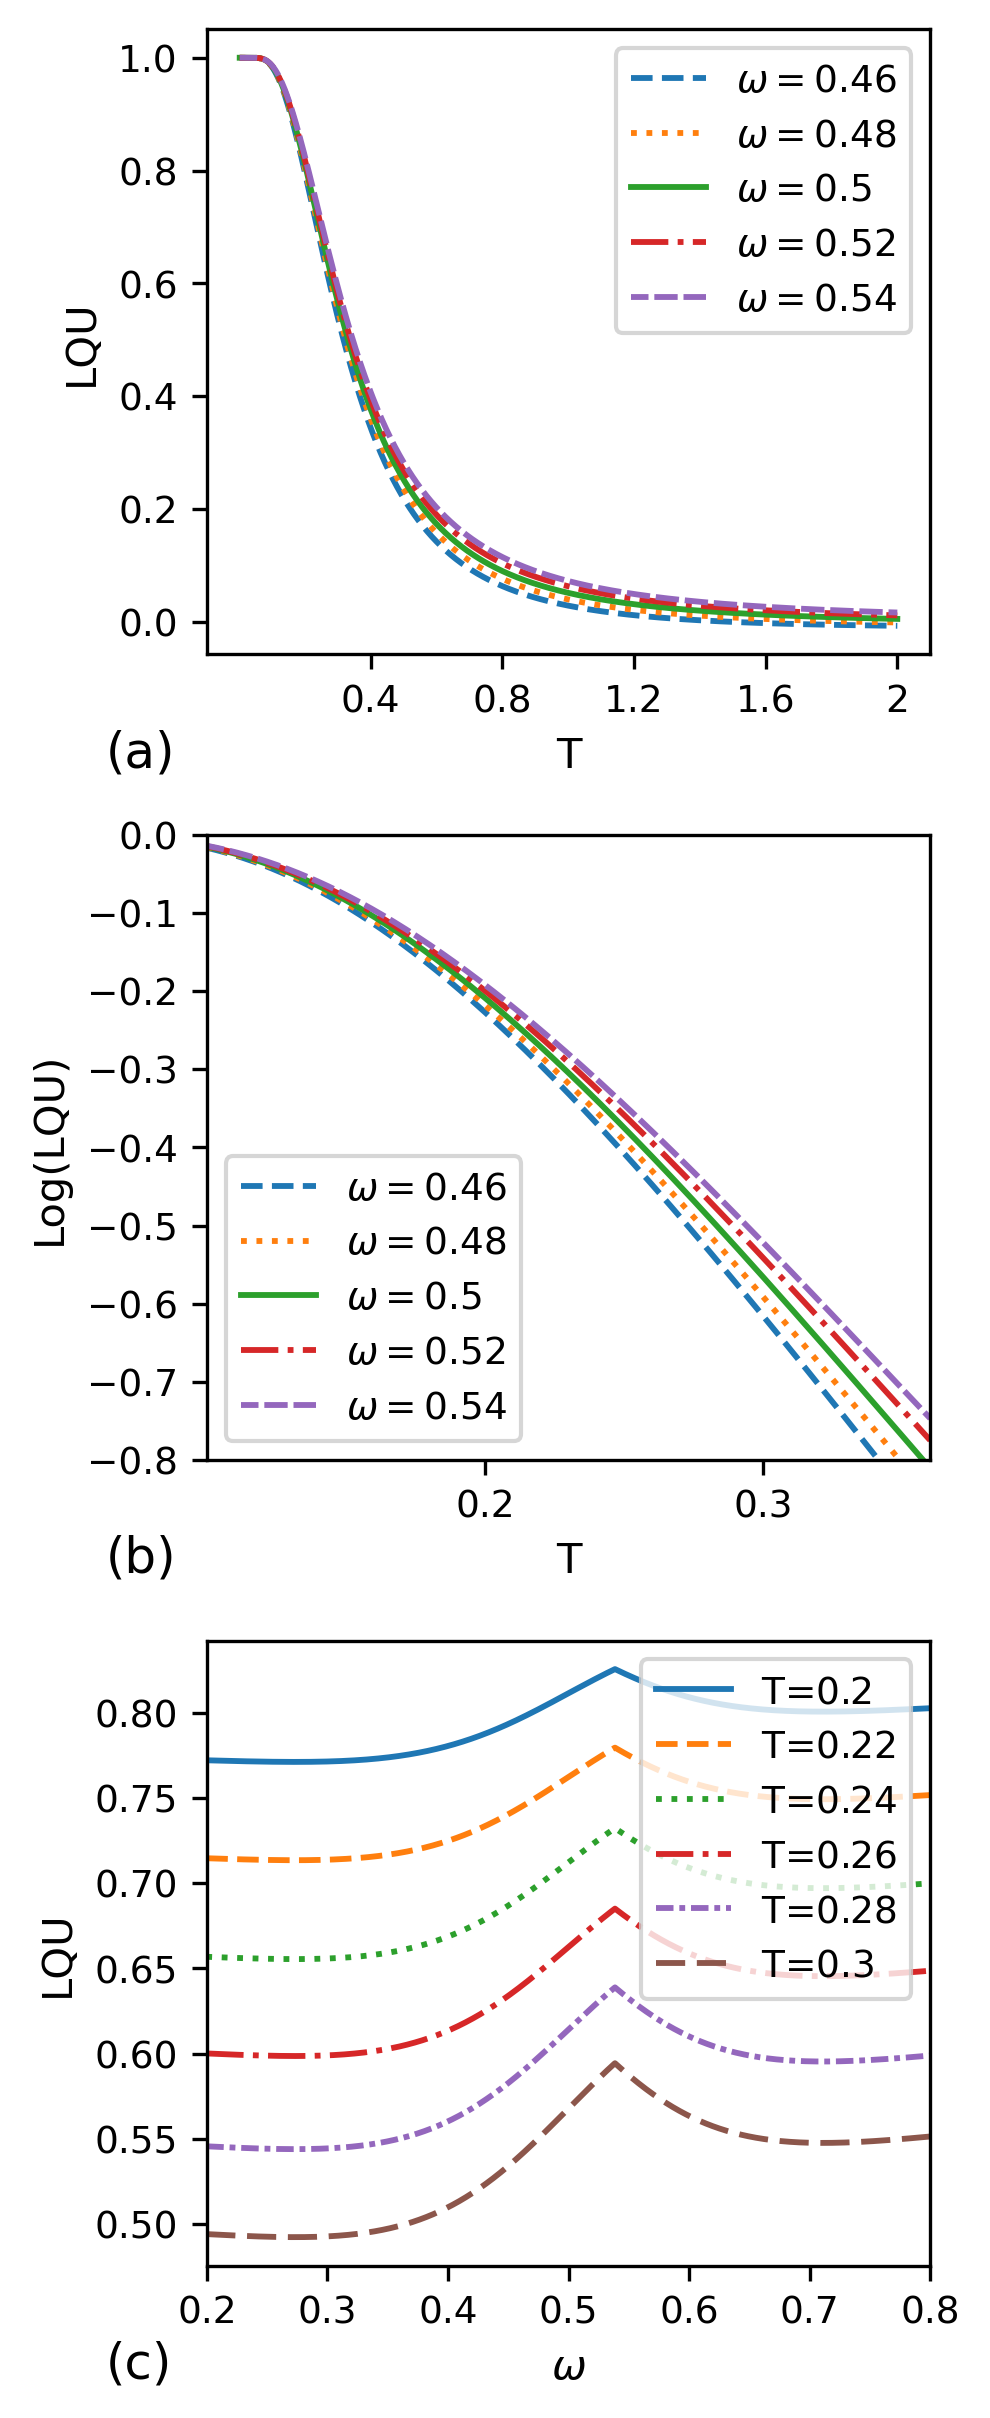

In [2]:

# ---------------------------------------------------------------------
# Tamaños de fuente (documento a 10pt, RevTeX 4-2 -> caption en \small = 9pt)
# ---------------------------------------------------------------------
FONTSIZE   = 10   # etiquetas de ejes (xlabel/ylabel)
TICKSIZE   = 9    # números de los ticks
LEGENDSIZE = 9    # texto de leyenda
LABELSIZE  = 12   # etiquetas (a), (b), (c) de cada panel

# Ancho de una columna en RevTeX 4-2 (twocolumn, aps, 10pt) ~ 3.4 in
COLWIDTH = 3.4

fig, axes = plt.subplots(3, 1, figsize=(COLWIDTH, COLWIDTH * 2.4), dpi=300)

# =======================================================================
# Panel (a): LQU vs T
# =======================================================================
ax = axes[0]
loglquticks_a = ['0.4', '0.8', '1.2', '1.6', '2']
x1_a = [.2, .4, .6, .8, 1]
x_a = np.linspace(0.001, 1, 10000)
linestyles = ['dashed', 'dotted', 'solid', 'dashdot', (0, (3, 1, 1, 0))]

for w, ls in zip(range(46, 56, 2), linestyles):
    w = .01 * w
    y = 1 - (2 / z(x_a)) * (lambda1(x_a) + 2 * xi * np.abs(lambda2(x_a) * Ref(w)))
    ax.plot(x_a, y, linestyle=ls, linewidth=1.4, label=r"$\omega=%s$" % round(w, 2))

ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel("LQU", fontsize=FONTSIZE)
ax.set_xticks(x1_a)
ax.set_xticklabels(loglquticks_a, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.legend(loc="best", fontsize=LEGENDSIZE)
ax.text(-0.14, -0.18, "(a)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
# Panel (b): Log(LQU) vs T
# =======================================================================
ax = axes[1]
loglquticks_b = ['0.2', '0.3']
x1_b = [.1, .15]
x_b = np.linspace(0.05, .2, 10000)
linestyles = ['dashed', 'dotted', 'solid', 'dashdot', (0, (3, 1, 1, 0))]

for w, ls in zip(range(46, 56, 2), linestyles):
    w = .01 * w
    y = np.log(1 - (2 / z(x_b)) * (lambda1(x_b) + 2 * xi * np.abs(lambda2(x_b) * Ref(w))))
    ax.plot(x_b, y, linestyle=ls, linewidth=1.4, label=r"$\omega=%s$" % round(w, 2))

ax.set_xlim(0.05, .18)
ax.set_ylim(-0.8, 0)
ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel("Log(LQU)", fontsize=FONTSIZE)
ax.set_xticks(x1_b)
ax.set_xticklabels(loglquticks_b, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.legend(loc="best", fontsize=LEGENDSIZE)
ax.text(-0.14, -0.18, "(b)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
# Panel (c): LQU vs omega, para varios T
# =======================================================================
ax = axes[2]
logxticks_c = [.2, .3, .4, .5, .6, .7, .8]
x_c = np.linspace(0, 5, 10000)
parametros = [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)]
linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 2))]

for (T, i), ls in zip(parametros, linestyles):
    T = .2 * J + .01 * T
    lqu = 1 - (2 / z(T)) * (lambda1(T) + 2 * xi * np.abs(lambda2(T) * Ref(x_c)))
    ax.plot(x_c, lqu, linestyle=ls, linewidth=1.4, label="T=$%s$" % round(.2 + .02 * i, 2))

ax.set_xlim(0.2, 0.8)
ax.set_xlabel(r"$\omega$", fontsize=FONTSIZE)
ax.set_ylabel("LQU", fontsize=FONTSIZE)
ax.set_xticks(logxticks_c)
ax.tick_params(axis='both', labelsize=TICKSIZE)
ax.legend(loc="upper right", fontsize=LEGENDSIZE)
ax.text(-0.14, -0.18, "(c)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
plt.tight_layout()
plt.savefig('3fig.pdf', dpi=300, bbox_inches='tight')